# Facial Expression Recognition Using CNN
**Eman Al Masri – 20230772 | Raneem Naji – 20230195 | Mohammad Khalaf – 20230243**


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torch.nn.functional as F
import cv2  
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
from torch.utils.data import Subset as _Subset
from sklearn.metrics import classification_report as _cr
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
DATA_DIR   = 'archive-3'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
TEST_DIR   = os.path.join(DATA_DIR, 'test')

IMG_SIZE    = 48
BATCH_SIZE  = 64
NUM_CLASSES = 7
VAL_SPLIT   = 0.1

CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [4]:
def count_images_per_class(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_images_per_class(TRAIN_DIR)
test_counts  = count_images_per_class(TEST_DIR)

print('Training set counts:')
for name, n in train_counts.items():
    print(f'  {name}: {n}')
print(f'  TOTAL: {sum(train_counts.values())}')

print('\nTest set counts:')
for name, n in test_counts.items():
    print(f'  {name}: {n}')
print(f'  TOTAL: {sum(test_counts.values())}')

Training set counts:
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171
  TOTAL: 28709

Test set counts:
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831
  TOTAL: 7178


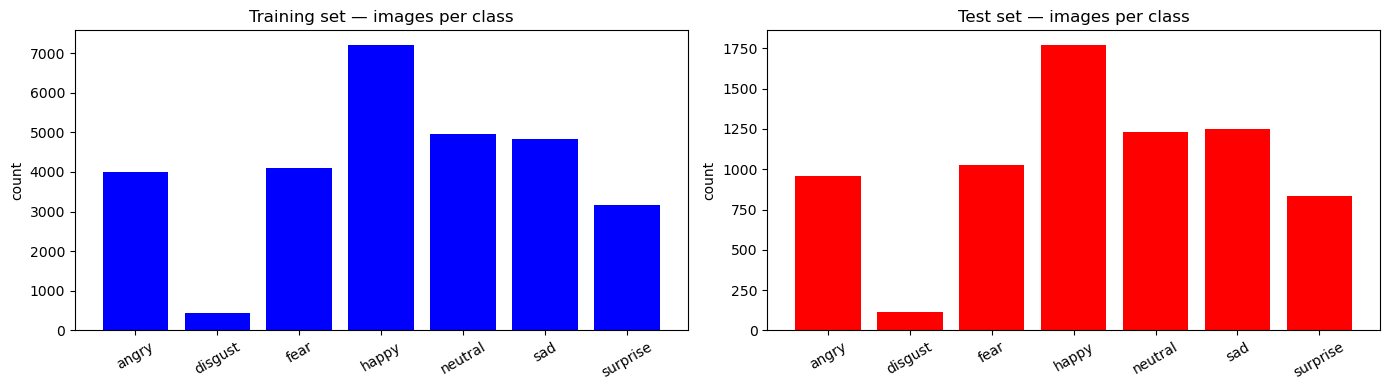

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(train_counts.keys(), train_counts.values(), color='blue')
ax[0].set_title('Training set — images per class')
ax[0].set_ylabel('count')
ax[0].tick_params(axis='x', rotation=30)

ax[1].bar(test_counts.keys(), test_counts.values(), color='red')
ax[1].set_title('Test set — images per class')
ax[1].set_ylabel('count')
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

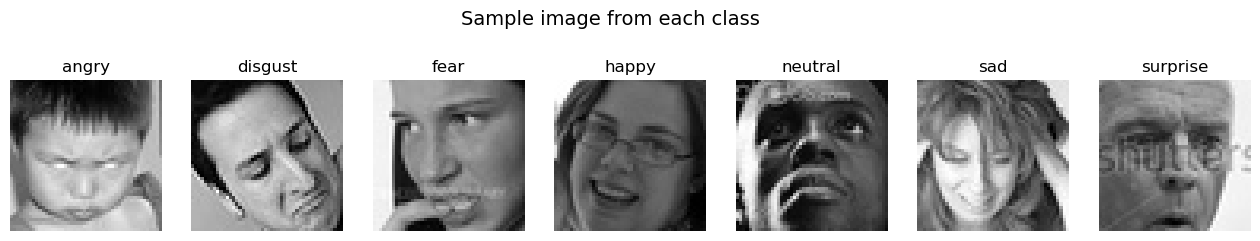

In [6]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 3))
fig.suptitle('Sample image from each class', fontsize=14)

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    sample_filename = os.listdir(class_dir)[0]
    img = Image.open(os.path.join(class_dir, sample_filename)).convert('L')
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(class_name)
    axes[i].axis('off')
plt.show()

In [7]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor(),            # → [0, 1] float, shape (1, 48, 48)
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


full_train_aug  = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
full_train_eval = datasets.ImageFolder(root=TRAIN_DIR, transform=eval_transform)
test_dataset    = datasets.ImageFolder(root=TEST_DIR,  transform=eval_transform)

n_total = len(full_train_aug)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(range(n_total), [n_train, n_val], generator=generator)

from torch.utils.data import Subset
train_dataset = Subset(full_train_aug,  train_indices.indices)
val_dataset   = Subset(full_train_eval, val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Test samples  : {len(test_dataset)}')

Train samples : 25839
Val samples   : 2870
Test samples  : 7178


In [8]:
images, labels = next(iter(train_loader))
print(f'Batch image shape : {images.shape}')   # (64, 1, 48, 48)
print(f'Batch label shape : {labels.shape}')   # (64,)
print(f'Pixel value range : {images.min():.3f} – {images.max():.3f}')
print(f'Example label     : {labels[0].item()} ({CLASS_NAMES[labels[0]]})')

Batch image shape : torch.Size([64, 1, 48, 48])
Batch label shape : torch.Size([64])
Pixel value range : 0.000 – 1.000
Example label     : 5 (sad)


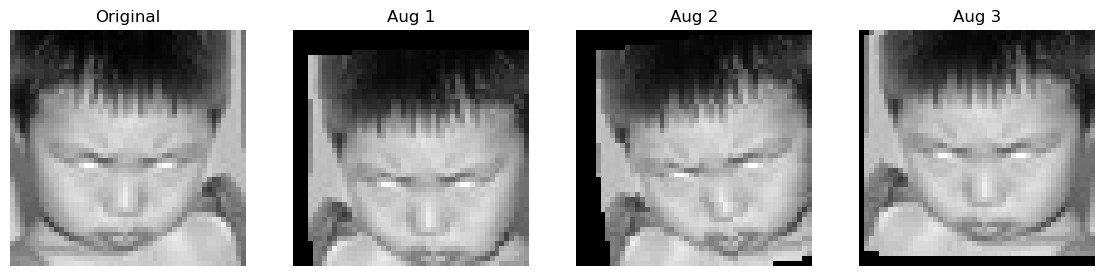

In [9]:
sample_img_path = os.path.join(TRAIN_DIR, CLASS_NAMES[0], os.listdir(os.path.join(TRAIN_DIR, CLASS_NAMES[0]))[0])
sample_pil = Image.open(sample_img_path).convert('L')

aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

fig, axs = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', 'Aug 1', 'Aug 2', 'Aug 3']
base = sample_pil.resize((IMG_SIZE, IMG_SIZE))
for ax, title in zip(axs, titles):
    img_show = base if title == 'Original' else aug_transform(sample_pil)
    ax.imshow(img_show, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.show()

In [10]:
def compute_class_weights(counts_dict, class_names):
    counts = np.array([counts_dict[name] for name in class_names], dtype=np.float32)
    tot = counts.sum()
    n_classes = len(class_names)
    weights = tot / (n_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)

CLASS_WEIGHTS = compute_class_weights(train_counts, CLASS_NAMES).to(DEVICE)

print('Class weights (higher = more emphasis):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i} {name}: {CLASS_WEIGHTS[i].item():.4f}')

Class weights (higher = more emphasis):
  0 angry: 1.0266
  1 disgust: 9.4066
  2 fear: 1.0010
  3 happy: 0.5684
  4 neutral: 0.8260
  5 sad: 0.8491
  6 surprise: 1.2934


In [11]:
class ConvBlock(nn.Module):
    """Two conv layers + BN + ReLU + MaxPool + Dropout."""
    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout),
        )

    def forward(self, x):
        return self.block(x)


class FER2013CNN(nn.Module):
    """
    4-block CNN for FER2013.
    Input : (B, 1, 48, 48)  — grayscale, already normalised to [0,1]
    Output: (B, 7)          — raw logits
    """
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,   64,  dropout=0.25),   # → (B,  64, 24, 24)
            ConvBlock(64,  128, dropout=0.25),   # → (B, 128, 12, 12)
            ConvBlock(128, 256, dropout=0.30),   # → (B, 256,  6,  6)
            ConvBlock(256, 512, dropout=0.30),   # → (B, 512,  3,  3)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)      # → (B, 512, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = FER2013CNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

FER2013CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.25, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(1

In [12]:
model.eval()
with torch.no_grad():
    dummy = torch.randn(4, 1, 48, 48).to(DEVICE)
    out   = model(dummy)
    print('Output shape:', out.shape)   # should be (4, 7)

Output shape: torch.Size([4, 7])


In [13]:
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

C:\Users\User\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += images.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += images.size(0)

    return running_loss / total, correct / total

In [15]:
EPOCHS = 90

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} acc {tr_acc*100:.2f}% | '
          f'val loss {vl_loss:.4f} acc {vl_acc*100:.2f}%')

print(f'\nBest validation accuracy: {best_val_acc*100:.2f}%')

Epoch   1/90 | train loss 2.4122 acc 15.05% | val loss 1.9453 acc 16.41%
Epoch   2/90 | train loss 2.1143 acc 15.95% | val loss 1.9279 acc 16.59%
Epoch   3/90 | train loss 2.0070 acc 16.82% | val loss 1.9303 acc 20.52%
Epoch   4/90 | train loss 1.9788 acc 17.07% | val loss 1.9440 acc 18.08%
Epoch   5/90 | train loss 1.9517 acc 16.79% | val loss 1.9629 acc 16.48%
Epoch   6/90 | train loss 1.9305 acc 18.23% | val loss 1.8972 acc 24.08%
Epoch   7/90 | train loss 1.9172 acc 19.15% | val loss 1.9208 acc 24.77%
Epoch   8/90 | train loss 1.8983 acc 21.05% | val loss 1.8198 acc 29.83%
Epoch   9/90 | train loss 1.8409 acc 22.70% | val loss 1.7757 acc 31.50%
Epoch  10/90 | train loss 1.7968 acc 24.84% | val loss 1.7098 acc 27.91%
Epoch  11/90 | train loss 1.7612 acc 28.38% | val loss 1.6654 acc 34.67%
Epoch  12/90 | train loss 1.6984 acc 32.95% | val loss 1.5254 acc 41.39%
Epoch  13/90 | train loss 1.6279 acc 38.08% | val loss 1.4650 acc 43.87%
Epoch  14/90 | train loss 1.5642 acc 40.14% | val l

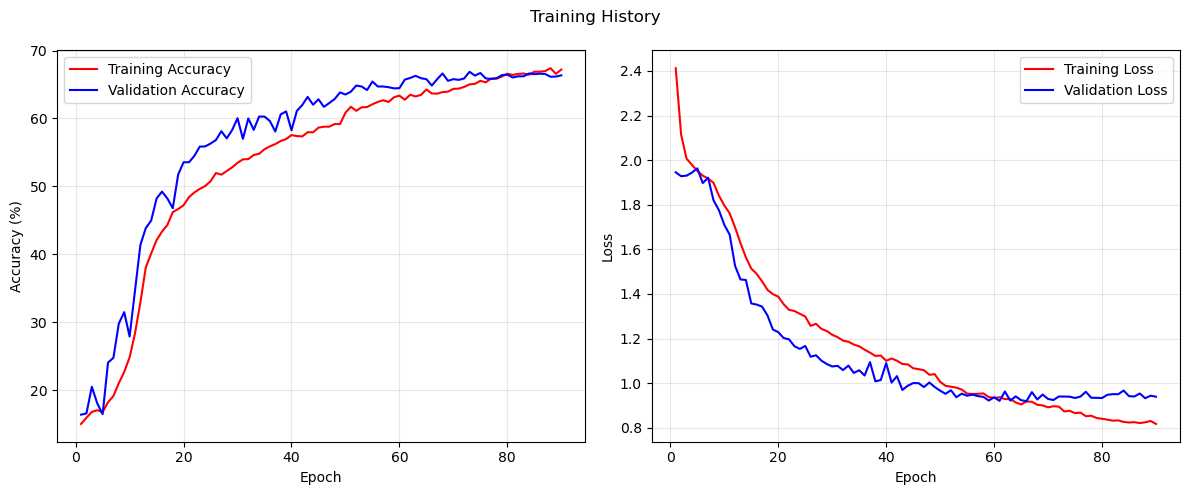

Best training accuracy  : 67.40%
Best validation accuracy: 66.86%


In [16]:
epochs_range = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Training History')

ax[0].plot(epochs_range, [a * 100 for a in history['train_acc']], 'r', label='Training Accuracy')
ax[0].plot(epochs_range, [a * 100 for a in history['val_acc']],   'b', label='Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy (%)')
ax[0].grid(alpha=0.3)

ax[1].plot(epochs_range, history['train_loss'], 'r', label='Training Loss')
ax[1].plot(epochs_range, history['val_loss'],   'b', label='Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best training accuracy  : {max(history["train_acc"])*100:.2f}%')
print(f'Best validation accuracy: {max(history["val_acc"])*100:.2f}%')

In [71]:
model.load_state_dict(best_model_state)
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = logits.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()

print(f'Test samples evaluated : {len(all_labels)}')
print(f'Unique predicted labels: {sorted(set(all_preds))}')


Test samples evaluated : 7178
Unique predicted labels: [0, 1, 2, 3, 4, 5, 6]


In [73]:
test_acc = accuracy_score(all_labels, all_preds)
print(f'\n{"="*55}')
print(f'  Overall Test Accuracy : {test_acc*100:.2f}%')
print(f'{"="*55}\n')

report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4
)
print('Classification Report (precision / recall / F1 / support):')
print(report)



  Overall Test Accuracy : 65.76%

Classification Report (precision / recall / F1 / support):
              precision    recall  f1-score   support

       angry     0.5538    0.6127    0.5818       958
     disgust     0.5232    0.7117    0.6031       111
        fear     0.5356    0.3818    0.4458      1024
       happy     0.8958    0.8478    0.8711      1774
     neutral     0.5793    0.6845    0.6275      1233
         sad     0.5341    0.5092    0.5213      1247
    surprise     0.7456    0.8183    0.7803       831

    accuracy                         0.6576      7178
   macro avg     0.6239    0.6523    0.6330      7178
weighted avg     0.6584    0.6576    0.6546      7178



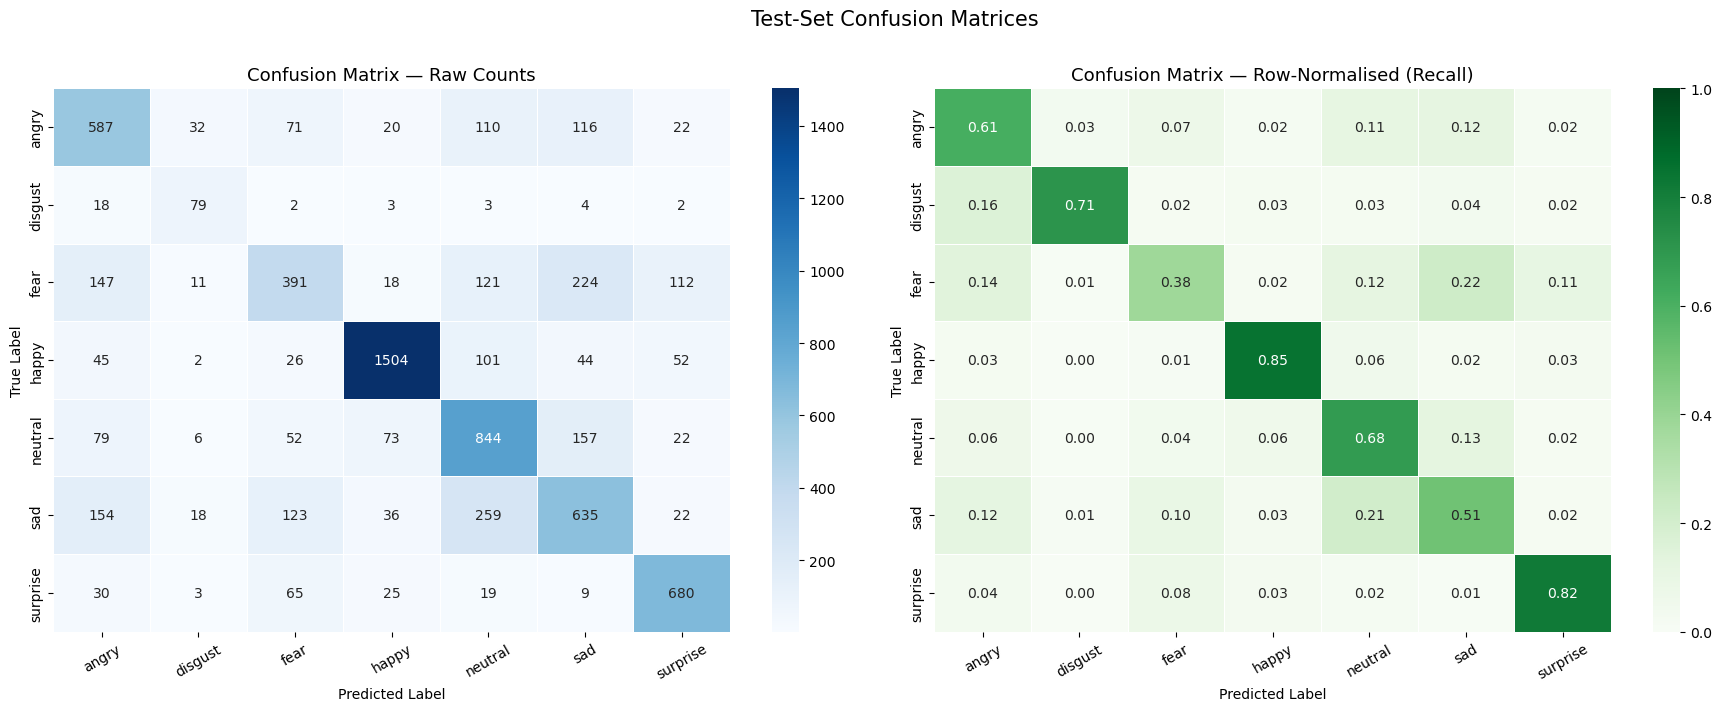

In [75]:

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix — Row-Normalised (Recall)', fontsize=13)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Test-Set Confusion Matrices', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


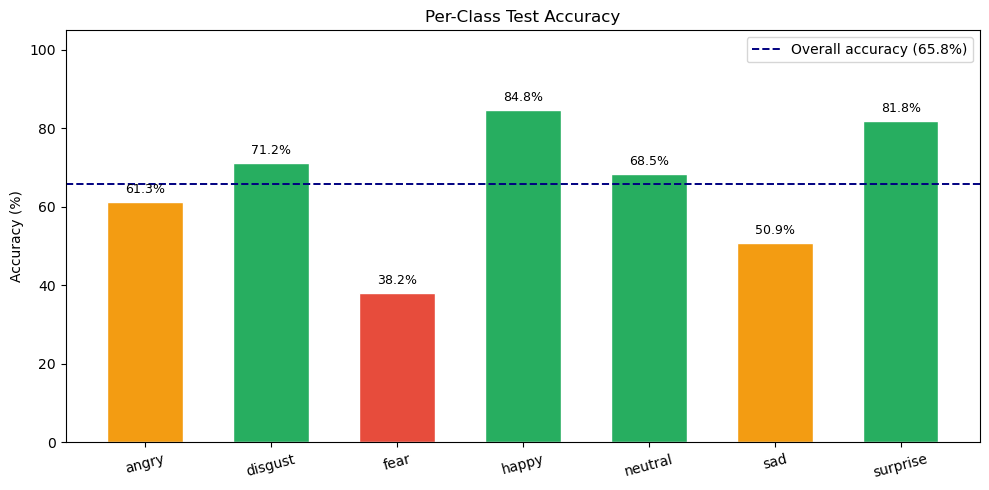

In [77]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#e74c3c' if a < 0.50 else '#f39c12' if a < 0.65 else '#27ae60'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', width=0.6)
ax.axhline(test_acc * 100, color='navy', linestyle='--', linewidth=1.4,
           label=f'Overall accuracy ({test_acc*100:.1f}%)')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy')
ax.legend()
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


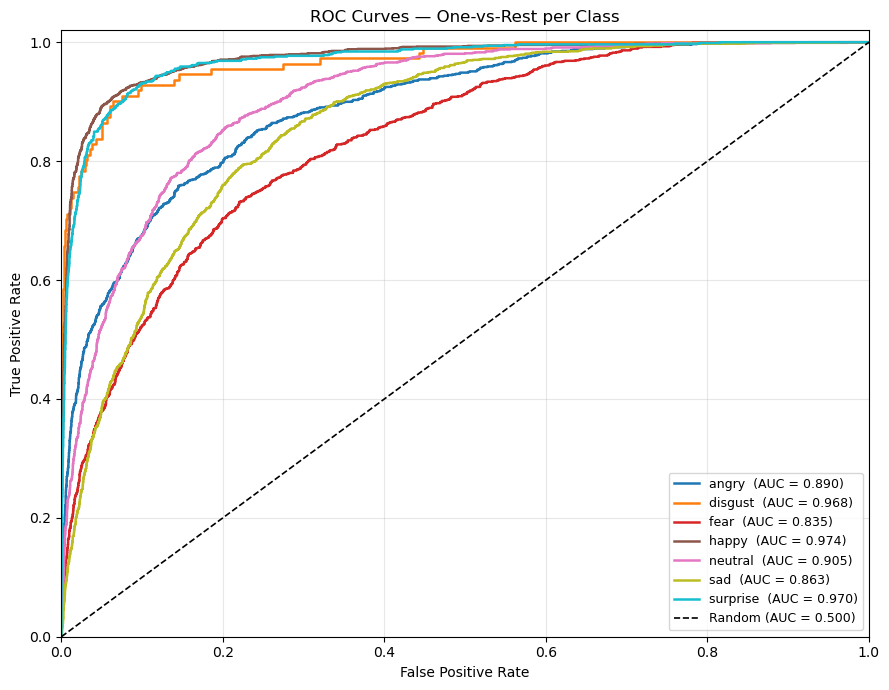

Macro-average AUC : 0.9148


In [79]:
y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

colors_roc = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

fig, ax = plt.subplots(figsize=(9, 7))
for i, (name, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc      = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=1.8,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest per Class')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_bin, all_probs, average='macro')
print(f'Macro-average AUC : {macro_auc:.4f}')


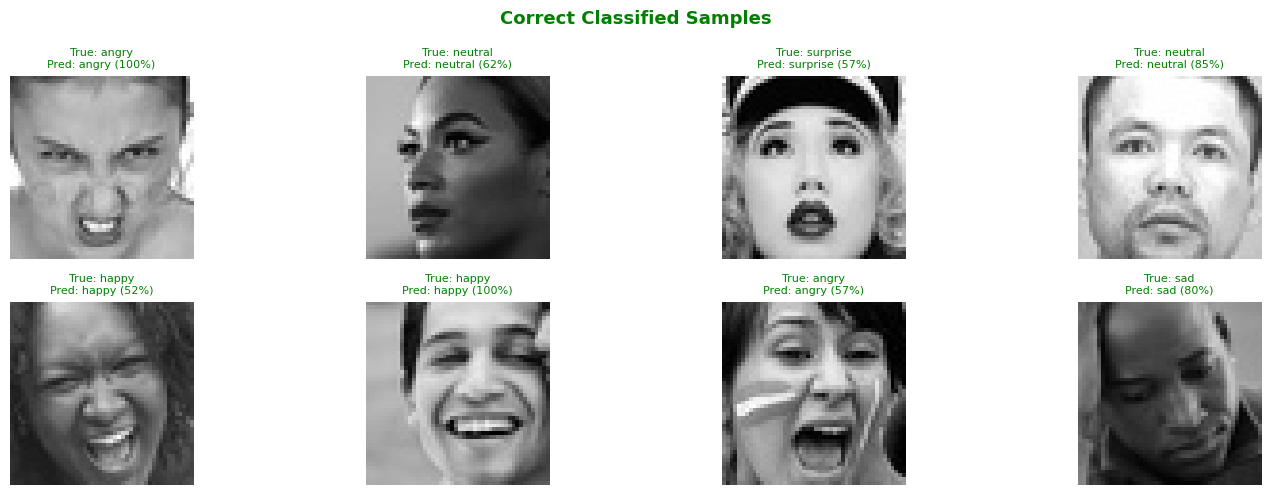

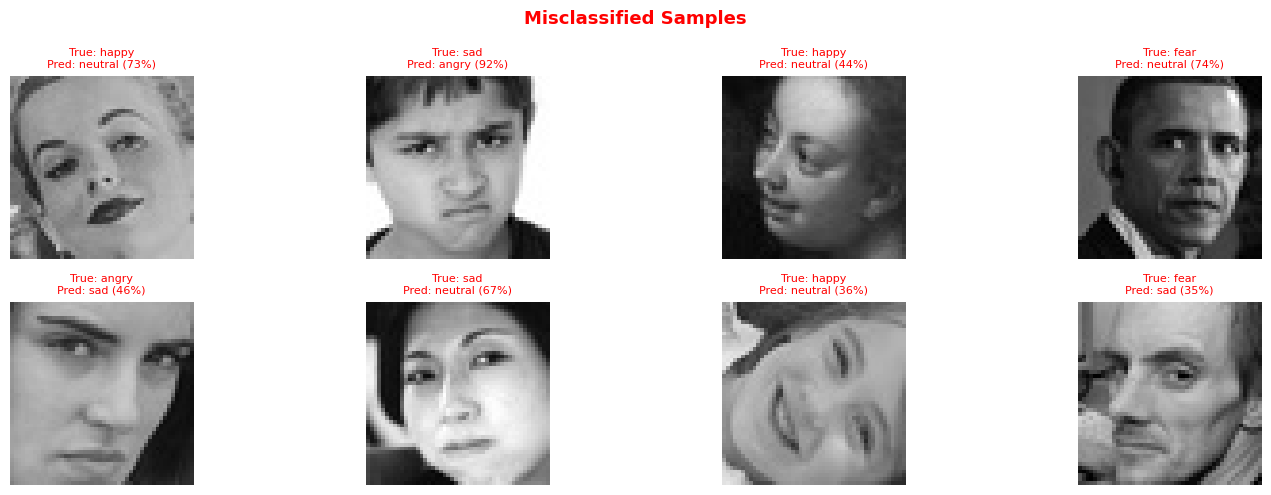

In [69]:

test_images_raw  = []
test_labels_raw  = []

raw_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
raw_test = datasets.ImageFolder(root=TEST_DIR, transform=raw_transform)
raw_loader = DataLoader(raw_test, batch_size=512, shuffle=False)

with torch.no_grad():
    for imgs, lbls in raw_loader:
        test_images_raw.append(imgs)
        test_labels_raw.append(lbls)

test_images_raw = torch.cat(test_images_raw)
test_labels_raw = torch.cat(test_labels_raw).numpy()

correct_idx   = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]

rng = np.random.default_rng(42)
sample_correct   = rng.choice(correct_idx,   size=min(8, len(correct_idx)),   replace=False)
sample_incorrect = rng.choice(incorrect_idx, size=min(8, len(incorrect_idx)), replace=False)

def show_samples(indices, title, fig_title_color):
    n = len(indices)
    fig, axes = plt.subplots(2, n // 2, figsize=(n * 1.9, 5))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=13, color=fig_title_color, fontweight='bold')
    for ax, idx in zip(axes, indices):
        img = test_images_raw[idx].squeeze().numpy()
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        true_lbl = CLASS_NAMES[all_labels[idx]]
        pred_lbl = CLASS_NAMES[all_preds[idx]]
        conf     = all_probs[idx, all_preds[idx]] * 100
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.0f}%)',
                     fontsize=8,
                     color='green' if true_lbl == pred_lbl else 'red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(sample_correct,   'Correct Classified Samples', 'green')
show_samples(sample_incorrect, 'Misclassified Samples',        'red')


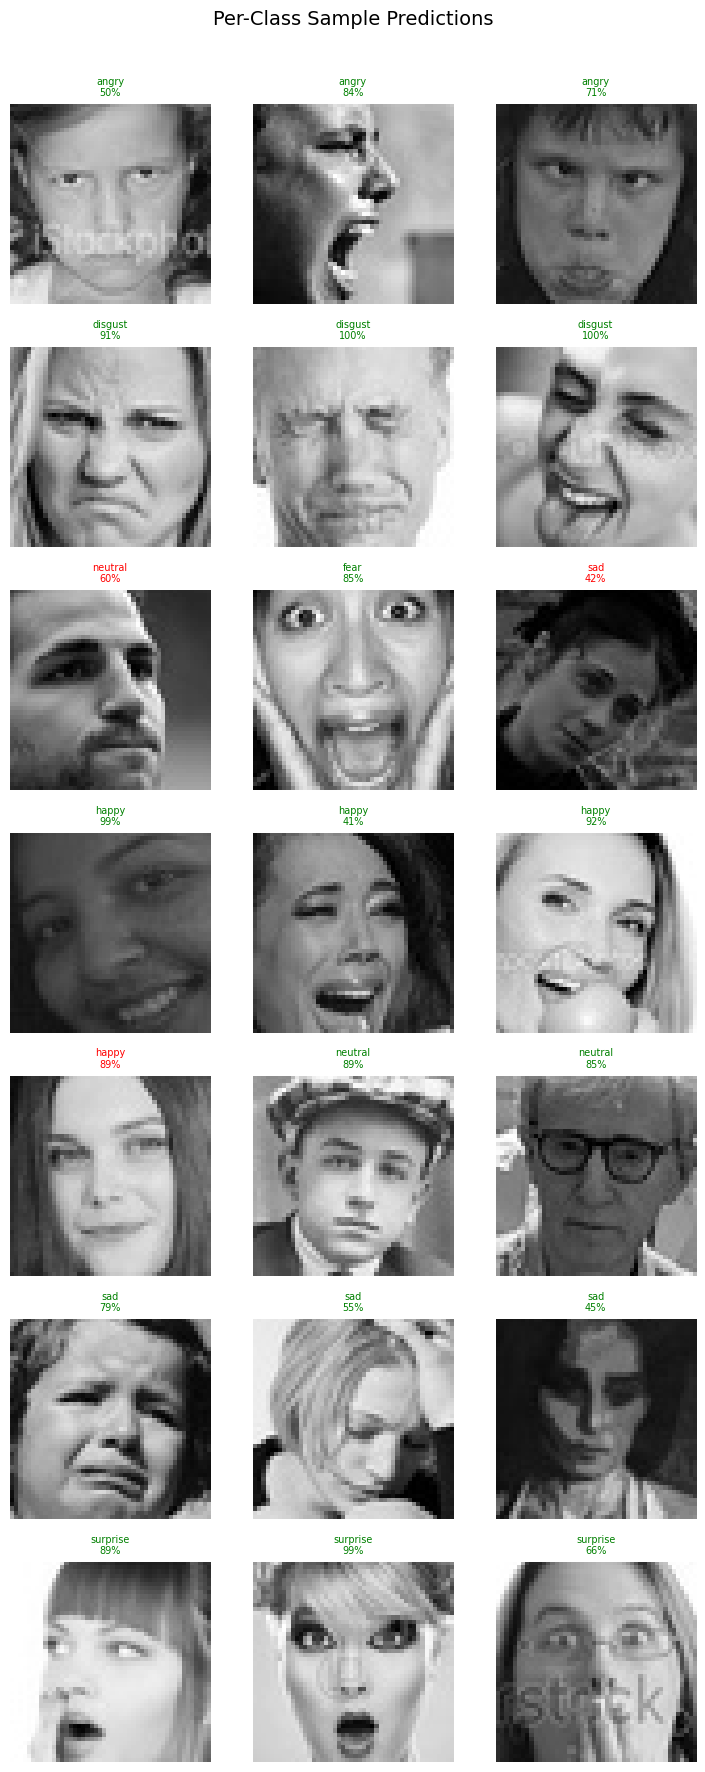

In [24]:
N_PER_CLASS = 3
fig, axes = plt.subplots(NUM_CLASSES, N_PER_CLASS,
                         figsize=(N_PER_CLASS * 2.5, NUM_CLASSES * 2.5))
fig.suptitle('Per-Class Sample Predictions', fontsize=14, y=1.01)

for row, class_idx in enumerate(range(NUM_CLASSES)):
    class_mask = np.where(all_labels == class_idx)[0]
    chosen = np.random.default_rng(class_idx).choice(
        class_mask, size=min(N_PER_CLASS, len(class_mask)), replace=False
    )
    for col, idx in enumerate(chosen):
        img       = test_images_raw[idx].squeeze().numpy()
        pred_lbl  = CLASS_NAMES[all_preds[idx]]
        conf      = all_probs[idx, all_preds[idx]] * 100
        correct   = all_preds[idx] == all_labels[idx]
        ax = axes[row][col]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        color = 'green' if correct else 'red'
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[class_idx], fontsize=10,
                          rotation=0, labelpad=50, va='center')
        ax.set_title(f'{pred_lbl}\n{conf:.0f}%', fontsize=7, color=color)

plt.tight_layout()
plt.show()


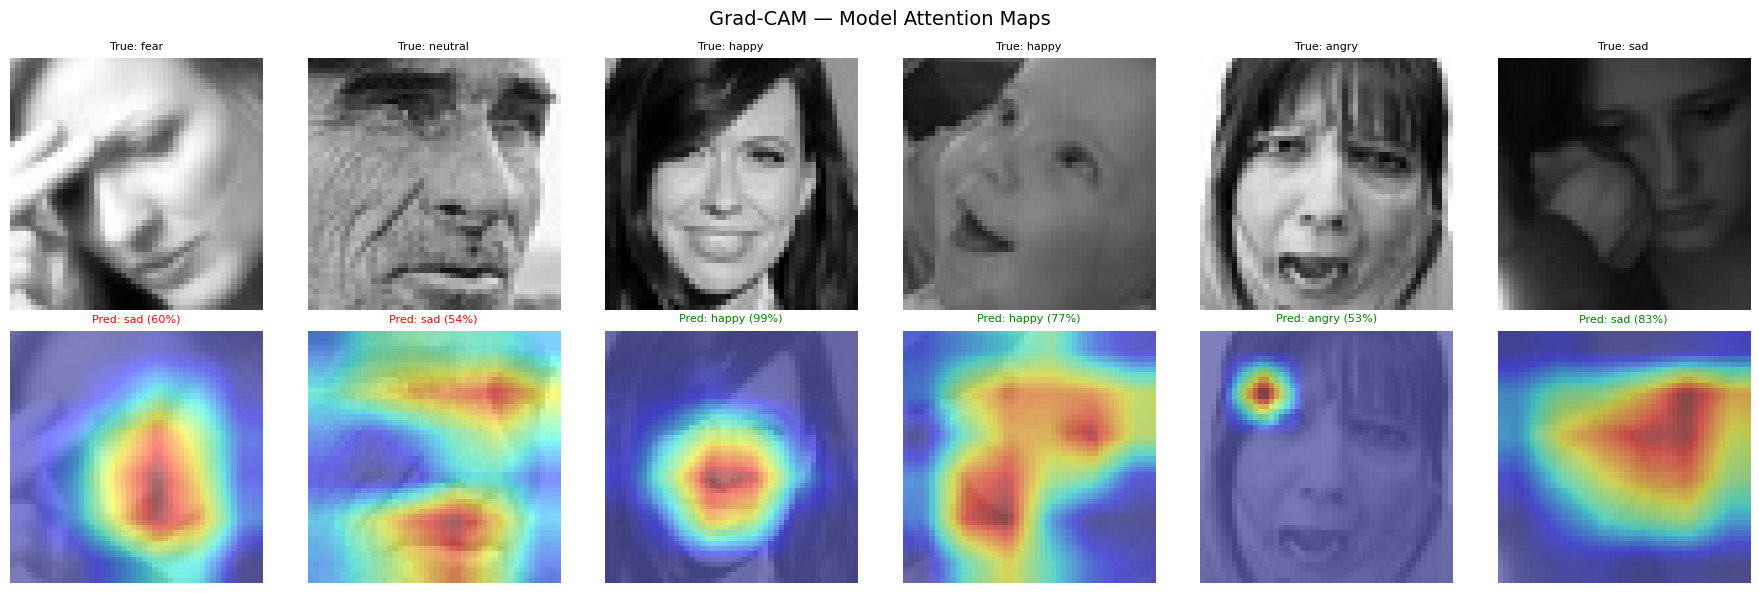

In [25]:
gradients = []
activations = []

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

def forward_hook(module, input, output):
    activations.append(output)

target_layer = model.features[-1].block[3]   
fwd_handle = target_layer.register_forward_hook(forward_hook)
bwd_handle = target_layer.register_full_backward_hook(backward_hook)

rng  = np.random.default_rng(0)
idxs = rng.choice(len(test_images_raw), size=6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Grad-CAM — Model Attention Maps', fontsize=14)

for col, idx in enumerate(idxs):
    gradients.clear(); activations.clear()

    inp = test_images_raw[idx].unsqueeze(0).to(DEVICE).requires_grad_(True)
    model.zero_grad()
    model.eval()
    logit = model(inp)
    pred_class = logit.argmax(dim=1).item()
    score = logit[0, pred_class]
    score.backward()

    grads = gradients[0].squeeze(0)               # (C, H, W)
    acts  = activations[0].squeeze(0)              # (C, H, W)
    weights = grads.mean(dim=(1, 2))               # (C,)
    cam = (weights[:, None, None] * acts).sum(0)   # (H, W)
    cam = F.relu(cam).detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    orig = test_images_raw[idx].squeeze().numpy()
    true_lbl = CLASS_NAMES[all_labels[idx]]
    pred_lbl = CLASS_NAMES[pred_class]
    conf     = torch.softmax(logit, dim=1)[0, pred_class].item() * 100
    correct  = pred_class == all_labels[idx]
    color    = 'green' if correct else 'red'

    axes[0][col].imshow(orig, cmap='gray', vmin=0, vmax=1)
    axes[0][col].set_title(f'True: {true_lbl}', fontsize=8)
    axes[0][col].axis('off')

    axes[1][col].imshow(orig, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    axes[1][col].imshow(cam_resized, cmap='jet', alpha=0.5)
    axes[1][col].set_title(f'Pred: {pred_lbl} ({conf:.0f}%)', fontsize=8, color=color)
    axes[1][col].axis('off')

fwd_handle.remove(); bwd_handle.remove()
plt.tight_layout()
plt.show()


In [26]:


report_dict = _cr(all_labels, all_preds,
                  target_names=CLASS_NAMES, output_dict=True)

df = pd.DataFrame(report_dict).T
df = df.rename(columns={'f1-score': 'f1', 'support': 'n_samples'})
df['n_samples'] = df['n_samples'].astype(int, errors='ignore')

print('\n' + '='*65)
print('  FINAL EVALUATION SUMMARY')
print('='*65)
print(df.round(4).to_string())
print('='*65)
print(f'  Overall Test Accuracy : {test_acc*100:.2f}%')
try:
    print(f'  Macro-average AUC     : {macro_auc:.4f}')
except NameError:
    pass
print('='*65)



  FINAL EVALUATION SUMMARY
              precision  recall      f1  n_samples
angry            0.5538  0.6127  0.5818        958
disgust          0.5232  0.7117  0.6031        111
fear             0.5356  0.3818  0.4458       1024
happy            0.8958  0.8478  0.8711       1774
neutral          0.5793  0.6845  0.6275       1233
sad              0.5341  0.5092  0.5213       1247
surprise         0.7456  0.8183  0.7803        831
accuracy         0.6576  0.6576  0.6576          0
macro avg        0.6239  0.6523  0.6330       7178
weighted avg     0.6584  0.6576  0.6546       7178
  Overall Test Accuracy : 65.76%
  Macro-average AUC     : 0.9148


In [53]:
torch.save(best_model_state, 'best_model.pth')

In [67]:
!python inference.py --checkpoint best_model.pth --input myface.jpg

Device : cuda
Loading checkpoint : best_model.pth
Model loaded  (4,821,703 parameters)

File       : myface.jpg
Prediction : HAPPY
Confidence : 97.76%

All class probabilities:
       happy  0.9776  #############################
     neutral  0.0216  
    surprise  0.0005  
       angry  0.0001  
        fear  0.0001  
         sad  0.0001  
     disgust  0.0000  


C:\Users\User\inference.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(checkpoint_path, map_location=device)


In [85]:
!python inference.py --checkpoint best_model.pth --input myface2.jpg

Device : cuda

C:\Users\User\inference.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(checkpoint_path, map_location=device)



Loading checkpoint : best_model.pth
Model loaded  (4,821,703 parameters)

File       : myface2.jpg
Prediction : HAPPY
Confidence : 90.17%

All class probabilities:
       happy  0.9017  
    surprise  0.0506  
        fear  0.0262  
         sad  0.0094  
     neutral  0.0064  
       angry  0.0054  
     disgust  0.0002  
